## Convert midi file into pandas dataframe
*same method also works with mido tracks or list of midi messages stored as dictionaries*

In [1]:
import pandas as pd
import mido

# can't iterate directly on midi file
# because it converts ticks to seconds
midi_file = mido.MidiFile('test.mid')
df = pd.DataFrame([
    # create a list of dictionaries which can be interpreted by pandas
    message.dict() for message in midi_file.tracks[0] if not message.is_meta
])


## Add category codes to dataset

In [2]:
# create a category type which enumarates labels in user defined order
cat_type = pd.CategoricalDtype(['note_on', 'note_off', 'control_change'], ordered=True)
# create a new series with the category codes
df['type_codes'] = df['type'].astype(cat_type).cat.codes


In [ ]:
# create a new series with shifted codes to use next code
# as current code and predict future
df['next_type'] = df['type_codes'].shift(-1, fill_value=0)


In [4]:
df.to_csv('test.csv')


## Create numpy array for data and target

In [5]:
# convert datafram to numpy array with .values droping
# the columns that we're not using
data = df.drop(columns=['type', 'channel', 'next_type']).values
# use a single column for the target (for KNN and some
# other algorithms is possible to use more)
target = df['next_type'].values


## Train KNN model and test for accuracy
*KNN does support multioutput classification (not regression) but it's accuracy evaluation method does not*

1


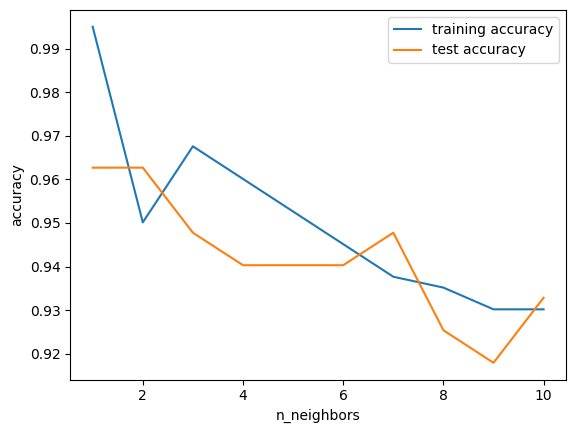

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# import SimpleImputer to replace NaN because not accepted in KNN
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# imputer object that replaces NaN with placeholder value -1
imputer = SimpleImputer(strategy='constant', fill_value=-1)
# impute data in one action with fit_transform()
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)

# test different settings
for n_neighbors in neighbors_settings:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    training_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
knn = KNeighborsClassifier(n_neighbors=highest_score_index)
print(highest_score_index)

# plotting
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()
